In [14]:
import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [15]:
X_train = joblib.load("../models/X_train.pkl")
X_test = joblib.load("../models/X_test.pkl")

y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [17]:
log_pred = log_model.predict(X_test)

In [18]:
accuracy_score(y_test, log_pred)

0.8076650106458482

In [19]:
confusion_matrix(y_test, log_pred)

array([[938,  98],
       [173, 200]])

In [20]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [22]:
rf_pred = rf_model.predict(X_test)

In [23]:
accuracy_score(y_test, rf_pred)

0.7963094393186657

In [24]:
confusion_matrix(y_test, rf_pred)

array([[944,  92],
       [195, 178]])

In [25]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



Two models were trained to predict customer churn:

1. Logistic Regression
2. Random Forest

Logistic Regression achieved an accuracy of 81%, slightly outperforming Random Forest (80%).

More importantly, Logistic Regression achieved higher recall for churn customers (54% vs 48%), making it more effective at identifying customers at risk of leaving.

Therefore, Logistic Regression was selected as the final model for this project.

In [31]:
df = pd.read_csv(r"C:\analytics portfolio\machine-learning-projects\customer-churn-prediction\data\Telcom-Customer-Churn.csv")

df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-1yr","1-2yr","2-4yr","4-6yr"]
)

df["avg_monthly_spend"] = df["TotalCharges"]/(df["tenure"]+1)

df = pd.get_dummies(df, drop_first=True)

feature_names = df.drop("Churn", axis=1).columns

In [32]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

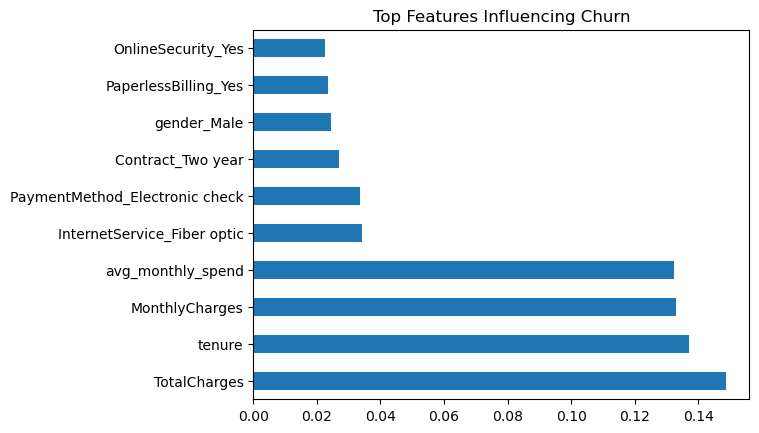

In [33]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind="barh")

plt.title("Top Features Influencing Churn")

plt.show()

In [34]:
plt.savefig("../visuals/feature_importance.png")

<Figure size 640x480 with 0 Axes>

In [35]:
probabilities = log_model.predict_proba(X_test)[:,1]

In [36]:
risk_df = pd.DataFrame({
    "Churn_Probability": probabilities
})

In [37]:
risk_df["Risk_Level"] = pd.cut(
    risk_df["Churn_Probability"],
    bins=[0,0.3,0.7,1],
    labels=["Low","Medium","High"]
)

In [38]:
risk_df.head()

,Churn_Probability,Risk_Level
0,0.704915,High
1,0.084423,Low
2,0.006635,Low
3,0.760683,High
4,0.007396,Low


In [39]:
import joblib

joblib.dump(log_model, "../models/churn_model.pkl")

['../models/churn_model.pkl']